In [ ]:
"""
=============================================================================
BORING BAR — PARAMETERS 2 & 3  WITH PAPER OPTIMAL ABSORBER TUNING (Eq.33)
=============================================================================

CORE IDEA
──────────
  Den Hartog (classical):  kd, cd from closed-form formula using ZERO-SPEED
  modal mass and natural frequency only. No Coriolis, Gyroscopic, Centrifugal
  or Rotational-Inertia are considered during tuning.

  Paper method  (Eq.33):  kd, cd chosen by maximising
      f_obj = sqrt( (1/n) * sum_{r=1}^{n}  a_lim(Omega_r, md) )
  where:
    • n = 13 speeds:  0, 500, 1000, …, 6000 RPM  (paper uses 12 steps)
    • a_lim(Omega_r) is computed from the FRF at THAT speed Omega_r
    • FRF at Omega_r INCLUDES all rotational effects:
        Coriolis  +  Gyroscopic  +  Centrifugal  +  Rotational inertia
    • Optimizer: Nelder-Mead (Ref [39] of paper)
    • Bounds: adaptive, scaled from Den Hartog values

  Result: a single (kd*, cd*) pair tuned to be optimal ON AVERAGE over
  the entire 0-6000 RPM operating range, accounting for the speed-
  dependent dynamics the bar actually experiences.

PARAMETERS SWEPT
────────────────
  Parameter 2 : Cavity length   L4  ∈ [40, 110] mm
  Parameter 3 : Cavity dia      di_cav ∈ [26, 44] mm  (wall ≥ 3 mm)

  Fixed (from Parameter-1 optimum): L_free = 20 mm  (tip to cavity start)

FOUR STABILITY-LOBE CASES (matching paper Figure 6 structure)
  1. No absorber           — zero-speed FRF  (baseline)
  2. Den Hartog absorber   — zero-speed FRF  (classical reference)
  3. Paper-optimal absorber— zero-speed FRF  (same kd*,cd* but FRF at Ω=0)
  4. Paper-optimal absorber— speed-dependent FRF  (proposed, best case)

OUTPUTS
  • Heat-maps of fn1, Mm, md, μ, kd*, cd*, alim ratios over the 2D grid
  • 3D surfaces
  • Stability lobe diagrams at best/worst/reference configurations
  • Natural frequency vs speed at best design
  • FRF comparison (direct + cross) showing Coriolis/gyro growth
  • 1D sensitivity slices
  • Full results table
=============================================================================
"""

import numpy as np
from scipy.optimize import brentq, minimize
from scipy.integrate import quad
from scipy.linalg import svd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from datetime import datetime
import json
import pickle
import hashlib
import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 1.  CONSTANTS
# ═══════════════════════════════════════════════════════════════════════════

E_body   = 280e9            # Pa
rho_body = 7850.0 * 1.2     # kg/m³
rho_WC   = 14_500.0         # kg/m³  tungsten-carbide damper
zeta_str = 0.01             # structural modal damping

L_total  = 0.300
D1_out   = 0.063; D_main = 0.050; di_body = 0.020
L1 = 0.040; L2 = 0.030
L_FREE   = 0.020            # fixed from Parameter-1 optimum (20 mm tip)
WALL_MIN = 0.003            # 3 mm minimum cavity wall
GAP_RAD  = 0.001            # 1 mm damper–cavity radial gap
CLR_AX   = 0.010            # 10 mm axial clearance

Nt = 2; Ktc = 2000e6; Krc = 500e6; ratio_kr = Krc / Ktc

# Sweep ranges
N_L4  = 8;  L4_arr   = np.linspace(0.040, 0.110, N_L4)
N_DI  = 8;  di_arr   = np.linspace(0.026, 0.044, N_DI)

# Paper Eq.(33): n = 13 speeds (0, 500, … 6000 RPM)
N_OPT_SPEEDS = 13
speeds_opt   = np.linspace(0, 6000, N_OPT_SPEEDS)

N_grid  = np.linspace(100, 6000, 400)
spd_plt = np.linspace(0, 6000, 200)

#SAVE = "/mnt/user-data/outputs"

print("=" * 70)
print("BORING BAR — PARAMETERS 2 & 3  (paper Eq.33 optimisation)")
print("=" * 70)
print(f"  L_free fixed = {L_FREE*1e3:.0f} mm  (Parameter-1 optimum)")
print(f"  L4   range = {L4_arr[0]*1e3:.0f}–{L4_arr[-1]*1e3:.0f} mm  ({N_L4} values)")
print(f"  di_cav range = {di_arr[0]*1e3:.0f}–{di_arr[-1]*1e3:.0f} mm  ({N_DI} values)")
print(f"  Optimisation speeds: {N_OPT_SPEEDS} points  (0, 500, …, 6000 RPM)")

BORING BAR — PARAMETERS 2 & 3  (paper Eq.33 optimisation)
  L_free fixed = 20 mm  (Parameter-1 optimum)
  L4   range = 40–110 mm  (8 values)
  di_cav range = 26–44 mm  (8 values)
  Optimisation speeds: 13 points  (0, 500, …, 6000 RPM)


In [ ]:
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

BASE_DIR = Path(
    "/content/drive/MyDrive/BoringBar_P23_Study"
)

CACHE_DIR = BASE_DIR / "Cache"
OPT_CACHE_DIR = BASE_DIR / "OptimizationCache"
PLOT_DIR = BASE_DIR / "Plots"
RESULT_DIR = BASE_DIR / "Results"
LOG_DIR = BASE_DIR / "Logs"

for d in [
    CACHE_DIR,
    OPT_CACHE_DIR,
    PLOT_DIR,
    RESULT_DIR,
    LOG_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

In [ ]:
def make_hash(data):

    txt = json.dumps(
        data,
        sort_keys=True,
        default=str
    )

    return hashlib.md5(
        txt.encode()
    ).hexdigest()


def load_geometry_case(case):

    case_id = make_hash(case)

    fname = CACHE_DIR / f"{case_id}.pkl"
#used fname is none, changed it to exists
    if fname.exists():
        if fname.stat().st_size == 0:
            print(f"✗ Cache file empty : {case_id}")
            return None

        with open(fname, "rb") as f:
            data = pickle.load(f)

        print(f"✓ Cache hit : {case_id}")

        return data

    return None


def save_geometry_case(case,result):

    case_id = make_hash(case)

    fname = CACHE_DIR / f"{case_id}.pkl"

    with open(fname, "wb") as f:
        pickle.dump(result, f)
    print(f"✓ Saved : {case_id}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 2.  CROSS-SECTION HELPERS
# ═══════════════════════════════════════════════════════════════════════════

def xsec(D_out, d_in=0.0):
    ro, ri = D_out/2, d_in/2
    A  = np.pi*(ro**2 - ri**2)
    I  = np.pi*(ro**4 - ri**4)/4
    Ip = np.pi*(ro**4 - ri**4)/2
    return A, I, Ip

# Pre-compute fixed sections 1, 2-avg, 3, 5
A1s,I1s,Ip1s = xsec(D1_out, di_body)
A3s,I3s,Ip3s = xsec(D_main, di_body)
A5s,I5s,Ip5s = xsec(D_main, 0.0)
_fr = np.linspace(0,1,300)
_Dv = D1_out + (D_main-D1_out)*_fr
A2s  = np.mean([xsec(d, di_body)[0] for d in _Dv])
I2s  = np.mean([xsec(d, di_body)[1] for d in _Dv])
Ip2s = np.mean([xsec(d, di_body)[2] for d in _Dv])

def P(b,z):  return np.array([np.cos(b*z), np.cosh(b*z), np.sin(b*z), np.sinh(b*z)])
def dP(b,z): return np.array([-b*np.sin(b*z), b*np.sinh(b*z), b*np.cos(b*z), b*np.cosh(b*z)])
def d2P(b,z):return np.array([-b**2*np.cos(b*z), b**2*np.cosh(b*z), -b**2*np.sin(b*z), b**2*np.sinh(b*z)])
def d3P(b,z):return np.array([b**3*np.sin(b*z), b**3*np.sinh(b*z), -b**3*np.cos(b*z), b**3*np.cosh(b*z)])

In [ ]:
import numpy as np
from scipy.optimize import brentq, minimize
from scipy.integrate import quad
from scipy.linalg import svd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings("ignore")
# ═══════════════════════════════════════════════════════════════════════════
# 3.  5-SECTION BEAM MODEL (same as Param-1)
# ═══════════════════════════════════════════════════════════════════════════

def make_arrays(di_cav, L4):
    """Per-section property arrays and z-boundaries for given (di_cav, L4)."""
    L5  = L_FREE
    L3  = L_total - L1 - L2 - L4 - L5
    if L3 < 0:
        return None
    A4,I4,Ip4 = xsec(D_main, di_cav)
    EI   = [E_body*I1s,  E_body*I2s,  E_body*I3s,  E_body*I4,  E_body*I5s]
    rhoA = [rho_body*A1s, rho_body*A2s, rho_body*A3s, rho_body*A4, rho_body*A5s]
    rhoI = [rho_body*I1s, rho_body*I2s, rho_body*I3s, rho_body*I4, rho_body*I5s]
    rhoIp= [rho_body*Ip1s,rho_body*Ip2s,rho_body*Ip3s,rho_body*Ip4,rho_body*Ip5s]
    c    = np.sqrt(np.array(EI)/np.array(rhoA))
    zb   = [0, L1, L1+L2, L1+L2+L3, L1+L2+L3+L4, L_total]
    return EI, rhoA, rhoI, rhoIp, c, zb, L3, L5


def char_mat(omega, EI, c, zb):
    bs = np.sqrt(omega/c)
    M  = np.zeros((20,20)); r = 0
    M[r,0:4]  = P(bs[0],zb[0]);             r+=1
    M[r,0:4]  = dP(bs[0],zb[0]);            r+=1
    M[r,16:20]= EI[4]*d2P(bs[4],zb[5]);     r+=1
    M[r,16:20]= EI[4]*d3P(bs[4],zb[5]);     r+=1
    for k in range(4):
        z=zb[k+1]; bl=bs[k]; br=bs[k+1]; EIl=EI[k]; EIr=EI[k+1]
        cl=4*k; cr=4*(k+1)
        M[r,cl:cl+4]=P(bl,z);   M[r,cr:cr+4]=-P(br,z);   r+=1
        M[r,cl:cl+4]=dP(bl,z);  M[r,cr:cr+4]=-dP(br,z);  r+=1
        M[r,cl:cl+4]=EIl*d2P(bl,z); M[r,cr:cr+4]=-EIr*d2P(br,z); r+=1
        M[r,cl:cl+4]=EIl*d3P(bl,z); M[r,cr:cr+4]=-EIr*d3P(br,z); r+=1
    return M


def find_and_compute(di_cav, L4):
    """
    Compute all modal quantities for a given (di_cav, L4).
    Returns a dict or None if geometry invalid / no root.
    """
    res = make_arrays(di_cav, L4)
    if res is None:
        return None
    EI, rhoA, rhoI, rhoIp, c, zb, L3, L5 = res

    # Scan for first natural frequency
    scan  = np.linspace(300, 55000, 80000)
    signs = []
    for om in scan:
        try:
            s,_ = np.linalg.slogdet(char_mat(om, EI, c, zb))
            signs.append(float(s))
        except:
            signs.append(0.0)
    wn1 = None
    for i in range(len(signs)-1):
        if signs[i]*signs[i+1] < 0 and signs[i]!=0 and signs[i+1]!=0:
            try:
                wn1 = brentq(
                    lambda o: float(np.linalg.slogdet(char_mat(o,EI,c,zb))[0]),
                    scan[i], scan[i+1], xtol=0.5)
                break
            except:
                pass
    if wn1 is None:
        return None

    # Mode-shape coefficients from null vector
    _,_,Vh = svd(char_mat(wn1, EI, c, zb))
    C_ = Vh[-1]
    bs = np.sqrt(wn1/c)

    def _raw(z):
        if   z<=zb[1]: return C_[ 0: 4]@P(bs[0],z)
        elif z<=zb[2]: return C_[ 4: 8]@P(bs[1],z)
        elif z<=zb[3]: return C_[ 8:12]@P(bs[2],z)
        elif z<=zb[4]: return C_[12:16]@P(bs[3],z)
        else:          return C_[16:20]@P(bs[4],z)
    def _draw(z):
        if   z<=zb[1]: return C_[ 0: 4]@dP(bs[0],z)
        elif z<=zb[2]: return C_[ 4: 8]@dP(bs[1],z)
        elif z<=zb[3]: return C_[ 8:12]@dP(bs[2],z)
        elif z<=zb[4]: return C_[12:16]@dP(bs[3],z)
        else:          return C_[16:20]@dP(bs[4],z)

    sc   = _raw(L_total)
    psi  = lambda z: _raw(z)/sc
    dpsi = lambda z: _draw(z)/sc

    # Modal integrals
    Mm  = sum(quad(lambda z: rhoA[k] *psi(z)**2, zb[k],zb[k+1],limit=150)[0] for k in range(5))
    Rii = sum(quad(lambda z: rhoI[k] *dpsi(z)**2,zb[k],zb[k+1],limit=150)[0] for k in range(5))
    Gii = sum(quad(lambda z: rhoIp[k]*dpsi(z)**2,zb[k],zb[k+1],limit=150)[0] for k in range(5))
    Km  = wn1**2 * Mm
    Cm  = 2.0*zeta_str*wn1*Mm
    zd     = (zb[3]+zb[4])/2
    PSI_zd = psi(zd)
    PSI_zf = psi(L_total)   # = 1.0

    # Damper mass
    V_cav  = np.pi*(di_cav/2)**2 * L4
    d_damp = di_cav - 2*0.001
    L_damp = L4 - CLR_AX
    V_damp = np.pi*(d_damp/2)**2 * L_damp
    while (V_damp/V_cav)>0.7:
        d_damp -= 0.001
        L_damp = L4 - CLR_AX
        V_damp = np.pi*(d_damp/2)**2 * L_damp
    md     = rho_WC * np.pi*(d_damp/2)**2 * L_damp
    mu     = md/Mm

    return dict(wn1=wn1, fn1=wn1/(2*np.pi), Mm=Mm, Rii=Rii, Gii=Gii,
                Km=Km, Cm=Cm, PSI_zd=PSI_zd, PSI_zf=PSI_zf, zd=zd, zb=zb,
                md=md, mu=mu,
                di_cav=di_cav, L4=L4, L3=L3, L5=L5)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 4.  SYSTEM MATRICES — Eq.(28) with all rotational effects
# ═══════════════════════════════════════════════════════════════════════════

def build_4x4(Om, r, kd, cd):
    """
    4×4 matrices for beam + absorber.
    All rotational effects:
      [M]+[M]_R (rotational inertia), [C]_Co (Coriolis),
      [C]_G (Gyroscopic), [K]_Ce (centrifugal)
    """
    Mm=r['Mm']; Rii=r['Rii']; Gii=r['Gii']
    Km=r['Km']; Cm=r['Cm']; pzd=r['PSI_zd']; md_=r['md']

    M11   = Mm + Rii                        # [M]+[M]_R
    K11   = Km - Om**2*Mm                   # beam centrifugal softening
    Ka    = kd - Om**2*md_                  # absorber centrifugal softening
    Cor   = 2*Om*Mm                         # Coriolis coupling
    Gyr   = 2*Om*Gii                        # Gyroscopic coupling
    C_off = Cor - Gyr                       # net u↔v off-diagonal
    Ca    = 2*Om*md_                        # absorber Coriolis

    M = np.diag([M11, md_, M11, md_])
    K = np.array([[K11+kd*pzd**2, -kd*pzd, 0, 0],
                  [-kd*pzd,        Ka,      0, 0],
                  [0, 0, K11+kd*pzd**2, -kd*pzd],
                  [0, 0, -kd*pzd,        Ka]])
    D = np.array([[Cm+cd*pzd**2, -cd*pzd,  C_off, 0],
                  [-cd*pzd,       cd,       0,     Ca],
                  [-C_off, 0, Cm+cd*pzd**2, -cd*pzd],
                  [0, -Ca, -cd*pzd,          cd]])
    return M, D, K


def build_2x2(Om, r):
    """2×2 matrices for beam WITHOUT absorber."""
    Mm=r['Mm']; Rii=r['Rii']; Gii=r['Gii']; Km=r['Km']; Cm=r['Cm']
    Cof = 2*Om*Mm - 2*Om*Gii
    M = np.diag([Mm+Rii, Mm+Rii])
    K = np.diag([Km-Om**2*Mm, Km-Om**2*Mm])
    D = np.array([[Cm, Cof], [-Cof, Cm]])
    return M, D, K

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 5.  DIRECTIONAL COEFFICIENTS (50 % up-milling, constant for all configs)
# ═══════════════════════════════════════════════════════════════════════════

_ph = np.linspace(0, np.pi/2, 80_000)
AXX = np.trapezoid(np.sin(_ph)*(-np.cos(_ph)-ratio_kr*np.sin(_ph)), _ph)
AXY = np.trapezoid(np.cos(_ph)*(-np.cos(_ph)-ratio_kr*np.sin(_ph)), _ph)
AYX = np.trapezoid(np.sin(_ph)*(np.sin(_ph) -ratio_kr*np.cos(_ph)), _ph)
AYY = np.trapezoid(np.cos(_ph)*(np.sin(_ph) -ratio_kr*np.cos(_ph)), _ph)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 6.  ALIM AT A SINGLE SPEED  (core inner loop, used by optimiser)
# ═══════════════════════════════════════════════════════════════════════════

def alim_single_speed(Om, r, kd, cd, freqs_hz):
    """
    Compute minimum a_lim (m) for given spindle speed Omega [rad/s].
    Uses FRF with ALL rotational effects included at that exact speed.
    This is what makes it the 'paper method' vs Den Hartog.
    """
    M, D, K = build_4x4(Om, r, kd, cd)
    PSI_zf  = r['PSI_zf']
    n   = 4; nb = 2
    fx  = np.zeros(n); fx[0]  = PSI_zf
    fy  = np.zeros(n); fy[nb] = PSI_zf
    alim_min = np.inf
    for fc in freqs_hz:
        wc = 2*np.pi*fc
        Z  = -wc**2*M + 1j*wc*D + K
        try:
            H   = np.linalg.solve(Z, np.column_stack([fx, fy]))
            hxx = PSI_zf*H[0,0];  hxy = PSI_zf*H[0,1]
            hyy = hxx;             hyx = hxy
            h11=AXX*hxx+AXY*hyx; h12=AXX*hxy+AXY*hyy
            h21=AYX*hxx+AYY*hyx; h22=AYX*hxy+AYY*hyy
            tr=h11+h22; dv=h11*h22-h12*h21
            if abs(dv) < 1e-60:
                continue
            disc=tr**2-4*dv; sq=np.sqrt(disc+0j)
            for lam in [(-tr+sq)/(2*dv), (-tr-sq)/(2*dv)]:
                rl=np.real(lam); il=np.imag(lam)
                if rl < 0:
                    al = -2*np.pi*rl/(Nt*Ktc)*(1+(il/rl)**2)
                    if 0 < al < alim_min:
                        alim_min = al
        except np.linalg.LinAlgError:
            pass
    return alim_min if alim_min != np.inf else 0.0

In [ ]:
def load_opt_cache(case):

    cid = make_hash(case)

    file = OPT_CACHE_DIR / f"{cid}.pkl"

    if file.exists():

        with open(file,"rb") as f:
            return pickle.load(f)

    return None


def save_opt_cache(case,data):

    cid = make_hash(case)

    with open(
        OPT_CACHE_DIR/f"{cid}.pkl",
        "wb"
    ) as f:

        pickle.dump(data,f)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 7.  PAPER EQ.(33) OPTIMISATION
# ═══════════════════════════════════════════════════════════════════════════
# maximize  f_obj(kd, cd) = sqrt( mean_{r=1..n}{ a_lim(Omega_r, md) } )
# The key is that a_lim(Omega_r) is evaluated with speed-dependent FRF
# (all rotational effects at Omega_r), NOT at zero speed.
# Bounds are adapted to the specific system (scale from Den Hartog values).

def den_hartog_params(r):
    mu      = r['mu']
    wd      = r['wn1'] / (1.0 + mu)
    zeta_dh = np.sqrt(3*mu/(8*(1+mu)))
    kd_dh   = r['md'] * wd**2
    cd_dh   = 2*zeta_dh * r['md'] * wd
    return kd_dh, cd_dh, mu, zeta_dh


def paper_optimise(r, verbose=False):
    """
    Find kd*, cd* using paper Eq.(33): Nelder-Mead on log10(kd), log10(cd).

    The CRITICAL DIFFERENCE vs Den Hartog:
      For each of the 13 optimisation speeds, the FRF includes
      Coriolis + Gyroscopic + Centrifugal + Rotational-inertia.
      Den Hartog uses none of these — it only sees the zero-speed properties.
    """
    kd_dh, cd_dh, _, _ = den_hartog_params(r)

    # Adaptive bounds — scale from Den Hartog so they make physical sense
    # for this particular boring bar geometry
    KD_LO = max(kd_dh * 0.05, 1e3)
    KD_HI = min(kd_dh * 20.0, 1e9)
    CD_LO = max(cd_dh * 0.02, 5.0)
    CD_HI = min(cd_dh * 10.0, 100_000.0)

    fn1    = r['fn1']
    freqs  = np.linspace(0.25*fn1, 2.5*fn1, 500)

    def neg_obj(log_x):
        kd = 10**log_x[0];  cd = 10**log_x[1]
        if kd < KD_LO or kd > KD_HI or cd < CD_LO or cd > CD_HI:
            return 1e10
        # Eq.(33): sqrt( (1/n) * sum alim(Omega_r) )
        vals = [alim_single_speed(rpm*2*np.pi/60, r, kd, cd, freqs)
                for rpm in speeds_opt]
        return -np.sqrt(np.mean(np.array(vals)))   # minimise negative

    x0  = [np.log10(kd_dh), np.log10(cd_dh)]
    res = minimize(neg_obj, x0, method='Nelder-Mead',
                   options={'xatol': 0.025, 'fatol': 1e-9,
                            'maxiter': 400, 'maxfev': 1200})

    kd_opt = float(np.clip(10**res.x[0], KD_LO, KD_HI))
    cd_opt = float(np.clip(10**res.x[1], CD_LO, CD_HI))
    obj    = -res.fun   # sqrt(mean alim) in metres

    if verbose:
        print(f"    DH: kd={kd_dh:.3e} cd={cd_dh:.1f}  |  "
              f"Opt: kd={kd_opt:.3e} cd={cd_opt:.1f}  obj={obj*1e3:.4f}mm")
    return kd_opt, cd_opt, kd_dh, cd_dh

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 8.  STABILITY LOBE ALGORITHM (pocket-speed, Budak-Altintas)
# ═══════════════════════════════════════════════════════════════════════════

def pocket_speed_lobes(r, kd, cd,
                        speed_dep=True, wc_pts=4000, max_lobe=20,
                        Nmin=100, Nmax=6100):
    """
    Full stability lobe cloud (N_rpm, alim_mm, fc_hz).
    speed_dep=True  → FRF rebuilt at each pocket speed (paper proposed method)
    speed_dep=False → FRF always at Ω=0 (classical method)
    """
    fn1    = r['fn1'];  wn1 = r['wn1'];  PSI_zf = r['PSI_zf']
    wc_arr = np.linspace(0.3*wn1, 2.5*wn1, wc_pts)
    M0,D0,K0 = build_4x4(0.0, r, kd, cd)
    N_o=[];  a_o=[];  fc_o=[]

    for wc in wc_arr:
        fc = wc/(2*np.pi)
        hxx0,hxy0 = _frf(wc, M0, D0, K0, PSI_zf)
        hyy0=hxx0; hyx0=hxy0
        h11=AXX*hxx0+AXY*hyx0; h12=AXX*hxy0+AXY*hyy0
        h21=AYX*hxx0+AYY*hyx0; h22=AYX*hxy0+AYY*hyy0
        tr=h11+h22; dv=h11*h22-h12*h21
        if abs(dv)<1e-60: continue
        disc=tr**2-4*dv; sq=np.sqrt(disc+0j)
        for lam in [(-tr+sq)/(2*dv),(-tr-sq)/(2*dv)]:
            rl=np.real(lam); il=np.imag(lam)
            if rl>=0: continue
            al=-2*np.pi*rl/(Nt*Ktc)*(1+(il/rl)**2)
            if al<=0 or al>0.020: break
            kappa  =il/rl; eps=np.pi-2*np.arctan(kappa)
            for k in range(max_lobe+1):
                dn=k+eps/(2*np.pi)
                if dn<=0: continue
                Np=60*fc/(Nt*dn)
                if not(Nmin<=Np<=Nmax): continue
                if speed_dep:
                    Mp,Dp,Kp=build_4x4(Np*2*np.pi/60, r, kd, cd)
                    hxx2,hxy2=_frf(wc,Mp,Dp,Kp,PSI_zf)
                    hyy2=hxx2; hyx2=hxy2
                    h11_=AXX*hxx2+AXY*hyx2; h12_=AXX*hxy2+AXY*hyy2
                    h21_=AYX*hxx2+AYY*hyx2; h22_=AYX*hxy2+AYY*hyy2
                    tr_=h11_+h22_; dv_=h11_*h22_-h12_*h21_
                    if abs(dv_)<1e-60: continue
                    disc_=tr_**2-4*dv_; sq_=np.sqrt(disc_+0j)
                    for lam_ in [(-tr_+sq_)/(2*dv_),(-tr_-sq_)/(2*dv_)]:
                        rl_=np.real(lam_); il_=np.imag(lam_)
                        if rl_<0:
                            al_=-2*np.pi*rl_/(Nt*Ktc)*(1+(il_/rl_)**2)
                            if al_>0:
                                kp2=il_/rl_; ep2=np.pi-2*np.arctan(kp2)
                                dn2=k+ep2/(2*np.pi)
                                if dn2>0:
                                    N2=60*fc/(Nt*dn2)
                                    if Nmin<=N2<=Nmax:
                                        N_o.append(N2); a_o.append(al_*1000); fc_o.append(fc)
                            break
                else:
                    N_o.append(Np); a_o.append(al*1000); fc_o.append(fc)
            break
    return np.array(N_o), np.array(a_o), np.array(fc_o)


def noabs_lobes(r, wc_pts=3000, max_lobe=20, Nmin=100, Nmax=6100):
    """Stability lobes with NO absorber (reference baseline)."""
    wn1=r['wn1']; PSI_zf=r['PSI_zf']
    wc_arr=np.linspace(0.3*wn1,2.5*wn1,wc_pts)
    M0,D0,K0=build_2x2(0.0,r)
    N_o=[];a_o=[];fc_o=[]
    for wc in wc_arr:
        fc=wc/(2*np.pi)
        hxx,hxy=_frf(wc,M0,D0,K0,PSI_zf); hyy=hxx; hyx=hxy
        h11=AXX*hxx+AXY*hyx;h12=AXX*hxy+AXY*hyy;h21=AYX*hxx+AYY*hyx;h22=AYX*hxy+AYY*hyy
        tr=h11+h22; dv=h11*h22-h12*h21
        if abs(dv)<1e-60: continue
        disc=tr**2-4*dv; sq=np.sqrt(disc+0j)
        for lam in [(-tr+sq)/(2*dv),(-tr-sq)/(2*dv)]:
            rl=np.real(lam); il=np.imag(lam)
            if rl<0:
                al=-2*np.pi*rl/(Nt*Ktc)*(1+(il/rl)**2)
                if 0<al<0.020:
                    kp=il/rl; ep=np.pi-2*np.arctan(kp)
                    for k in range(max_lobe+1):
                        dn=k+ep/(2*np.pi)
                        if dn>0:
                            Np=60*fc/(Nt*dn)
                            if Nmin<=Np<=Nmax: N_o.append(Np);a_o.append(al*1000);fc_o.append(fc)
                break
    return np.array(N_o),np.array(a_o),np.array(fc_o)


def _frf(wc, M, D, K, PSI_zf):
    n=M.shape[0]; nb=n//2
    fx=np.zeros(n); fx[0]=PSI_zf; fy=np.zeros(n); fy[nb]=PSI_zf
    Z=-wc**2*M+1j*wc*D+K
    try:
        H=np.linalg.solve(Z,np.column_stack([fx,fy]))
        return PSI_zf*H[0,0], PSI_zf*H[0,1]
    except: return 0j, 0j


def lower_env(N, a, Ng, win=100.0):
    env=np.full(len(Ng),np.nan)
    for i,Ngi in enumerate(Ng):
        m=np.abs(N-Ngi)<win
        if m.sum()>0: env[i]=a[m].min()
    return env


def min_alim_from_env(env):
    v=env[~np.isnan(env)]; return v.min() if len(v)>0 else 0.0

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 9.  MAIN SWEEP
# ═══════════════════════════════════════════════════════════════════════════

# Result matrices indexed [i_L4, j_di]
fn1_M   = np.full((N_L4,N_DI),np.nan); Mm_M    = np.full((N_L4,N_DI),np.nan)
PSI_M   = np.full((N_L4,N_DI),np.nan); md_M    = np.full((N_L4,N_DI),np.nan)
mu_M    = np.full((N_L4,N_DI),np.nan)
kd_dh_M = np.full((N_L4,N_DI),np.nan); cd_dh_M = np.full((N_L4,N_DI),np.nan)
kd_op_M = np.full((N_L4,N_DI),np.nan); cd_op_M = np.full((N_L4,N_DI),np.nan)
al_na_M  = np.full((N_L4,N_DI),np.nan)
al_dh_M  = np.full((N_L4,N_DI),np.nan)   # DH, zero-speed
al_op0_M = np.full((N_L4,N_DI),np.nan)   # opt, zero-speed
al_opS_M = np.full((N_L4,N_DI),np.nan)   # opt, speed-dep
ratio_dh_M  = np.full((N_L4,N_DI),np.nan)
ratio_op0_M = np.full((N_L4,N_DI),np.nan)
ratio_opS_M = np.full((N_L4,N_DI),np.nan)
res_store   = [[None]*N_DI for _ in range(N_L4)]

hdr = (f"{'L4':>6} {'di':>6} {'wall':>5} {'fn1':>7} {'Mm':>7} {'ψ(zd)':>7} "
       f"{'md':>7} {'μ':>6} {'kd_DH':>10} {'kd_opt':>10} {'cd_DH':>7} {'cd_opt':>7} "
       f"{'al_na':>7} {'al_DH':>7} {'al_op0':>7} {'al_opS':>7} {'ratio_S':>8}")
print(f"\n{hdr}")
print("-"*130)

for i, L4 in enumerate(L4_arr):
    for j, di_cav in enumerate(di_arr):
        wall = (D_main-di_cav)/2
        if wall < WALL_MIN-1e-6:
            continue

        # ── compute beam modal properties
        case = {"L4": float(L4),"di_cav": float(di_cav)}

        cached = load_geometry_case(case)

        if cached is not None:

            r = cached

        else:

            r = find_and_compute(di_cav,L4)

            if r is not None:
                save_geometry_case(case,r)

            else:
                print(f"  {L4*1e3:5.0f}  {di_cav*1e3:6.0f}  SKIP")
                continue

        # ── Den Hartog (no rotational effects in tuning)
        kd_dh, cd_dh, mu, _ = den_hartog_params(r)

        # ── Paper Eq.(33) optimisation (rotational effects included)
        print(f"  L4={L4*1e3:.0f}mm di={di_cav*1e3:.0f}mm ... ", end='', flush=True)
        opt_case = {
                    "L4": float(L4),
                    "di_cav": float(di_cav),
                    "md": float(r["md"]),
                    "fn1": float(r["fn1"])
                }

        opt = load_opt_cache(opt_case)

        if opt is not None:

            kd_opt = opt["kd_opt"]
            cd_opt = opt["cd_opt"]

        else:

            kd_opt, cd_opt, _, _ = paper_optimise(r)

            save_opt_cache(
                case=opt_case,
                data={
                    "kd_opt": kd_opt,
                    "cd_opt": cd_opt
                }
            )
        kd_opt, cd_opt, _, _ = paper_optimise(r, verbose=True)

        # ── No-absorber baseline lobes
        N_na, a_na, _ = noabs_lobes(r, wc_pts=2500)
        env_na = lower_env(N_na, a_na, N_grid)
        alim_na = min_alim_from_env(env_na)

        # ── DH absorber, zero-speed FRF
        N_dh, a_dh, _ = pocket_speed_lobes(r, kd_dh, cd_dh, speed_dep=False, wc_pts=3000)
        env_dh = lower_env(N_dh, a_dh, N_grid)
        alim_dh = min_alim_from_env(env_dh)

        # ── Paper-optimal, zero-speed FRF (same kd*,cd* but no speed dependence)
        N_op0, a_op0, _ = pocket_speed_lobes(r, kd_opt, cd_opt, speed_dep=False, wc_pts=3000)
        env_op0 = lower_env(N_op0, a_op0, N_grid)
        alim_op0 = min_alim_from_env(env_op0)

        # ── Paper-optimal, speed-dependent FRF (proposed full method)
        N_opS, a_opS, _ = pocket_speed_lobes(r, kd_opt, cd_opt, speed_dep=True, wc_pts=3500)
        env_opS = lower_env(N_opS, a_opS, N_grid)
        alim_opS = min_alim_from_env(env_opS)

        # Store
        fn1_M[i,j]=r['fn1']; Mm_M[i,j]=r['Mm']; PSI_M[i,j]=r['PSI_zd']
        md_M[i,j]=r['md'];   mu_M[i,j]=mu
        kd_dh_M[i,j]=kd_dh/1e6; cd_dh_M[i,j]=cd_dh
        kd_op_M[i,j]=kd_opt/1e6; cd_op_M[i,j]=cd_opt
        al_na_M[i,j]=alim_na*1e3
        al_dh_M[i,j]=alim_dh*1e3
        al_op0_M[i,j]=alim_op0*1e3
        al_opS_M[i,j]=alim_opS*1e3
        r_na = alim_na if alim_na>0 else 1e-9
        ratio_dh_M[i,j]  = alim_dh/r_na
        ratio_op0_M[i,j] = alim_op0/r_na
        ratio_opS_M[i,j] = alim_opS/r_na
        res_store[i][j] = dict(r=r, kd_dh=kd_dh, cd_dh=cd_dh,
                                kd_opt=kd_opt, cd_opt=cd_opt,
                                env_na=env_na, env_dh=env_dh,
                                env_op0=env_op0, env_opS=env_opS)

        print(f"  {L4*1e3:5.0f}  {di_cav*1e3:5.0f}  {wall*1e3:5.1f}  "
              f"{r['fn1']:7.1f}  {r['Mm']:7.4f}  {r['PSI_zd']:7.4f}  "
              f"{r['md']:7.4f}  {mu:6.3f}  {kd_dh/1e6:10.4f}  {kd_opt/1e6:10.4f}  "
              f"{cd_dh:7.1f}  {cd_opt:7.1f}  "
              f"{alim_na*1e3:7.4f}  {alim_dh*1e3:7.4f}  "
              f"{alim_op0*1e3:7.4f}  {alim_opS*1e3:7.4f}  {alim_opS/r_na:8.2f}×")

# ── best configuration (by paper-optimal speed-dep improvement)
best_idx  = np.unravel_index(np.nanargmax(ratio_opS_M), ratio_opS_M.shape)
worst_idx = np.unravel_index(np.nanargmin(ratio_opS_M), ratio_opS_M.shape)
i_b,j_b = best_idx; i_w,j_w = worst_idx
L4_best=L4_arr[i_b]; di_best=di_arr[j_b]
sto_b = res_store[i_b][j_b]; sto_w = res_store[i_w][j_w]

print(f"\n★ OPTIMUM: L4={L4_best*1e3:.0f}mm, di={di_best*1e3:.0f}mm  "
      f"ratio={ratio_opS_M[i_b,j_b]:.2f}×  "
      f"fn1={fn1_M[i_b,j_b]:.0f}Hz  md={md_M[i_b,j_b]:.3f}kg")


    L4     di  wall     fn1      Mm   ψ(zd)      md      μ      kd_DH     kd_opt   cd_DH  cd_opt   al_na   al_DH  al_op0  al_opS  ratio_S
----------------------------------------------------------------------------------------------------------------------------------
✗ Cache file empty : bae07278bdb58faac62feb9758a6cdea
✓ Saved : bae07278bdb58faac62feb9758a6cdea
  L4=40mm di=26mm ...     DH: kd=1.794e+06 cd=287.7  |  Opt: kd=2.089e+06 cd=244.1  obj=106.6365mm
     40     26   12.0    569.5   1.0622   0.7977   0.1968   0.185      1.7936      2.0887    287.7    244.1  700.1640  7294.8931  9471.3815  9669.5004     13.81×
✓ Saved : 04640da5d9d5850c2f2674e1f0e47282
  L4=40mm di=29mm ...     DH: kd=2.084e+06 cd=377.4  |  Opt: kd=2.511e+06 cd=330.6  obj=110.2865mm
     40     29   10.7    576.8   1.0359   0.7977   0.2412   0.233      2.0844      2.5114    377.4    330.6  700.8152  7962.1994  10541.9987  10704.4000     15.27×
✓ Saved : 512bacc2e61ab3a70e0dbe77f0365ee2
  L4=40mm di=31mm ...  

In [ ]:
rows = []

for i,L4 in enumerate(L4_arr):

    for j,di in enumerate(di_arr):

        if np.isnan(fn1_M[i,j]):
            continue

        rows.append({

            "L4_mm": L4*1000,
            "di_mm": di*1000,

            "fn1_Hz": fn1_M[i,j],

            "Mm_kg": Mm_M[i,j],

            "md_kg": md_M[i,j],

            "mu": mu_M[i,j],

            "kd_DH_MNm": kd_dh_M[i,j],

            "kd_OPT_MNm": kd_op_M[i,j],

            "cd_DH": cd_dh_M[i,j],

            "cd_OPT": cd_op_M[i,j],

            "ratio_DH": ratio_dh_M[i,j],

            "ratio_OPT": ratio_opS_M[i,j]
        })

df = pd.DataFrame(rows)

df.to_csv(
    RESULT_DIR /
    f"p23_results_{RUN_ID}.csv",
    index=False
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 10.  NATURAL FREQUENCY vs SPEED AT BEST DESIGN
# ═══════════════════════════════════════════════════════════════════════════

def nat_freqs_vs_speed(r, kd, cd, speeds):
    fw=[]; bw=[]; ab=[]
    for rpm in speeds:
        Om=rpm*2*np.pi/60
        M,D,K=build_4x4(Om,r,kd,cd)
        sz=M.shape[0]; A=np.zeros((2*sz,2*sz)); Mi=np.linalg.inv(M)
        A[:sz,:sz]=-Mi@D; A[:sz,sz:]=-Mi@K; A[sz:,:sz]=np.eye(sz)
        evs=np.linalg.eigvals(A)
        fs=sorted(np.abs(evs.imag)/(2*np.pi)); fs=[f for f in fs if f>5]
        dedup=[]
        for f in fs:
            if not dedup or abs(f-dedup[-1])>0.5: dedup.append(f)
        wh=r['fn1']; beam=[f for f in dedup if 0.3*wh<f<3.5*wh]
        abm=[f for f in dedup if abs(f-np.sqrt(kd/r['md'])/(2*np.pi))<400]
        if len(beam)>=2: bw.append(beam[0]); fw.append(beam[-1])
        elif len(beam)==1: bw.append(beam[0]); fw.append(beam[0])
        else: bw.append(np.nan); fw.append(np.nan)
        ab.append(abm[0] if abm else np.nan)
    return np.array(fw), np.array(bw), np.array(ab)

print("Computing nat-freqs vs speed at best design …")
r_b=sto_b['r']
fw_opt,bw_opt,ab_opt=nat_freqs_vs_speed(r_b, sto_b['kd_opt'], sto_b['cd_opt'], spd_plt)
fw_dh, bw_dh, ab_dh =nat_freqs_vs_speed(r_b, sto_b['kd_dh'],  sto_b['cd_dh'],  spd_plt)

# FRFs at selected speeds — direct and cross
freqs_frf=[]; f=50
while f<2.5*r_b['fn1']: freqs_frf.append(f); f*=1.003
freqs_frf=np.array(freqs_frf)
frf_rpms=[0,2000,4000,6000]; clrs_frf=["#333","#1A80C4","#27AE60","#E77728"]
FD_opt=[]; FC_opt=[]; FD_dh=[]; FC_dh=[]
for rpm in frf_rpms:
    Om=rpm*2*np.pi/60
    Mo,Do,Ko=build_4x4(Om,r_b,sto_b['kd_opt'],sto_b['cd_opt'])
    Md,Dd,Kd=build_4x4(Om,r_b,sto_b['kd_dh'], sto_b['cd_dh'])
    FD_opt.append(np.abs([_frf(2*np.pi*f,Mo,Do,Ko,r_b['PSI_zf'])[0] for f in freqs_frf]))
    FC_opt.append(np.abs([_frf(2*np.pi*f,Mo,Do,Ko,r_b['PSI_zf'])[1] for f in freqs_frf]))
    FD_dh.append( np.abs([_frf(2*np.pi*f,Md,Dd,Kd,r_b['PSI_zf'])[0] for f in freqs_frf]))
    FC_dh.append( np.abs([_frf(2*np.pi*f,Md,Dd,Kd,r_b['PSI_zf'])[1] for f in freqs_frf]))

Computing nat-freqs vs speed at best design …


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 11.  PLOTTING
# ═══════════════════════════════════════════════════════════════════════════

plt.rcParams.update({"font.family":"DejaVu Sans","font.size":9,
                     "axes.titlesize":9,"axes.labelsize":9,
                     "xtick.labelsize":8,"ytick.labelsize":8,
                     "lines.linewidth":1.5,"figure.dpi":150})
L4_mm=L4_arr*1e3; di_mm=di_arr*1e3

In [ ]:
# ── FIG 1 — Heat maps ──────────────────────────────────────────────────────
fig1=plt.figure(figsize=(20,12)); fig1.suptitle(
    "Parameters 2 & 3 — Paper Eq.(33) Optimisation\n"
    "kd*, cd* maximise sqrt(mean(alim)) over 13 speeds with all rotational effects",
    fontsize=11,fontweight='bold',y=1.00)
gs1=gridspec.GridSpec(3,4,figure=fig1,hspace=0.50,wspace=0.40,
                       left=0.04,right=0.97,top=0.92,bottom=0.06)

def hmap(ax,data,title,cmap,fmt="{:.2f}"):
    im=ax.imshow(data.T,origin='lower',aspect='auto',cmap=cmap,
                  extent=[L4_mm[0],L4_mm[-1],di_mm[0],di_mm[-1]])
    plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
    for ii in range(N_L4):
        for jj in range(N_DI):
            if not np.isnan(data[ii,jj]):
                ax.text(L4_mm[ii],di_mm[jj],fmt.format(data[ii,jj]),
                        ha='center',va='center',fontsize=6,
                        color='white' if data[ii,jj]>np.nanpercentile(data,70) else 'k')
    ax.plot(L4_best*1e3,di_best*1e3,'w*',ms=14,zorder=5)
    ax.set_xlabel("L4 [mm]"); ax.set_ylabel("di_cav [mm]"); ax.set_title(title)

hmap(fig1.add_subplot(gs1[0,0]),ratio_opS_M, "Improvement ratio\nPaper-opt speed-dep.","YlOrRd")
hmap(fig1.add_subplot(gs1[0,1]),ratio_op0_M, "Improvement ratio\nPaper-opt zero-speed","Oranges")
hmap(fig1.add_subplot(gs1[0,2]),ratio_dh_M,  "Improvement ratio\nDen Hartog zero-speed","Blues")
hmap(fig1.add_subplot(gs1[0,3]),al_opS_M,    "Min alim paper-opt\nspeed-dep. [mm]",     "RdYlGn","{:.3f}")
hmap(fig1.add_subplot(gs1[1,0]),fn1_M,       "$f_{n1}$ [Hz]",                           "viridis","{:.0f}")
hmap(fig1.add_subplot(gs1[1,1]),mu_M,        "Mass ratio μ",                            "plasma","{:.2f}")
hmap(fig1.add_subplot(gs1[1,2]),kd_op_M,     "kd* paper-opt [MN/m]",                   "cividis","{:.2f}")
hmap(fig1.add_subplot(gs1[1,3]),cd_op_M,     "cd* paper-opt [N·s/m]",                  "copper","{:.0f}")
hmap(fig1.add_subplot(gs1[2,0]),kd_dh_M,     "kd Den Hartog [MN/m]",                   "Blues","{:.2f}")
hmap(fig1.add_subplot(gs1[2,1]),cd_dh_M,     "cd Den Hartog [N·s/m]",                  "Greens","{:.0f}")
hmap(fig1.add_subplot(gs1[2,2]),md_M,        "Damper mass md [kg]",                    "autumn","{:.2f}")
hmap(fig1.add_subplot(gs1[2,3]),PSI_M,       r"Mode shape $\psi(z_d)$",                "RdYlGn","{:.3f}")

plt.tight_layout()

fig1.savefig(
    PLOT_DIR /
    f"heatmaps_{RUN_ID}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

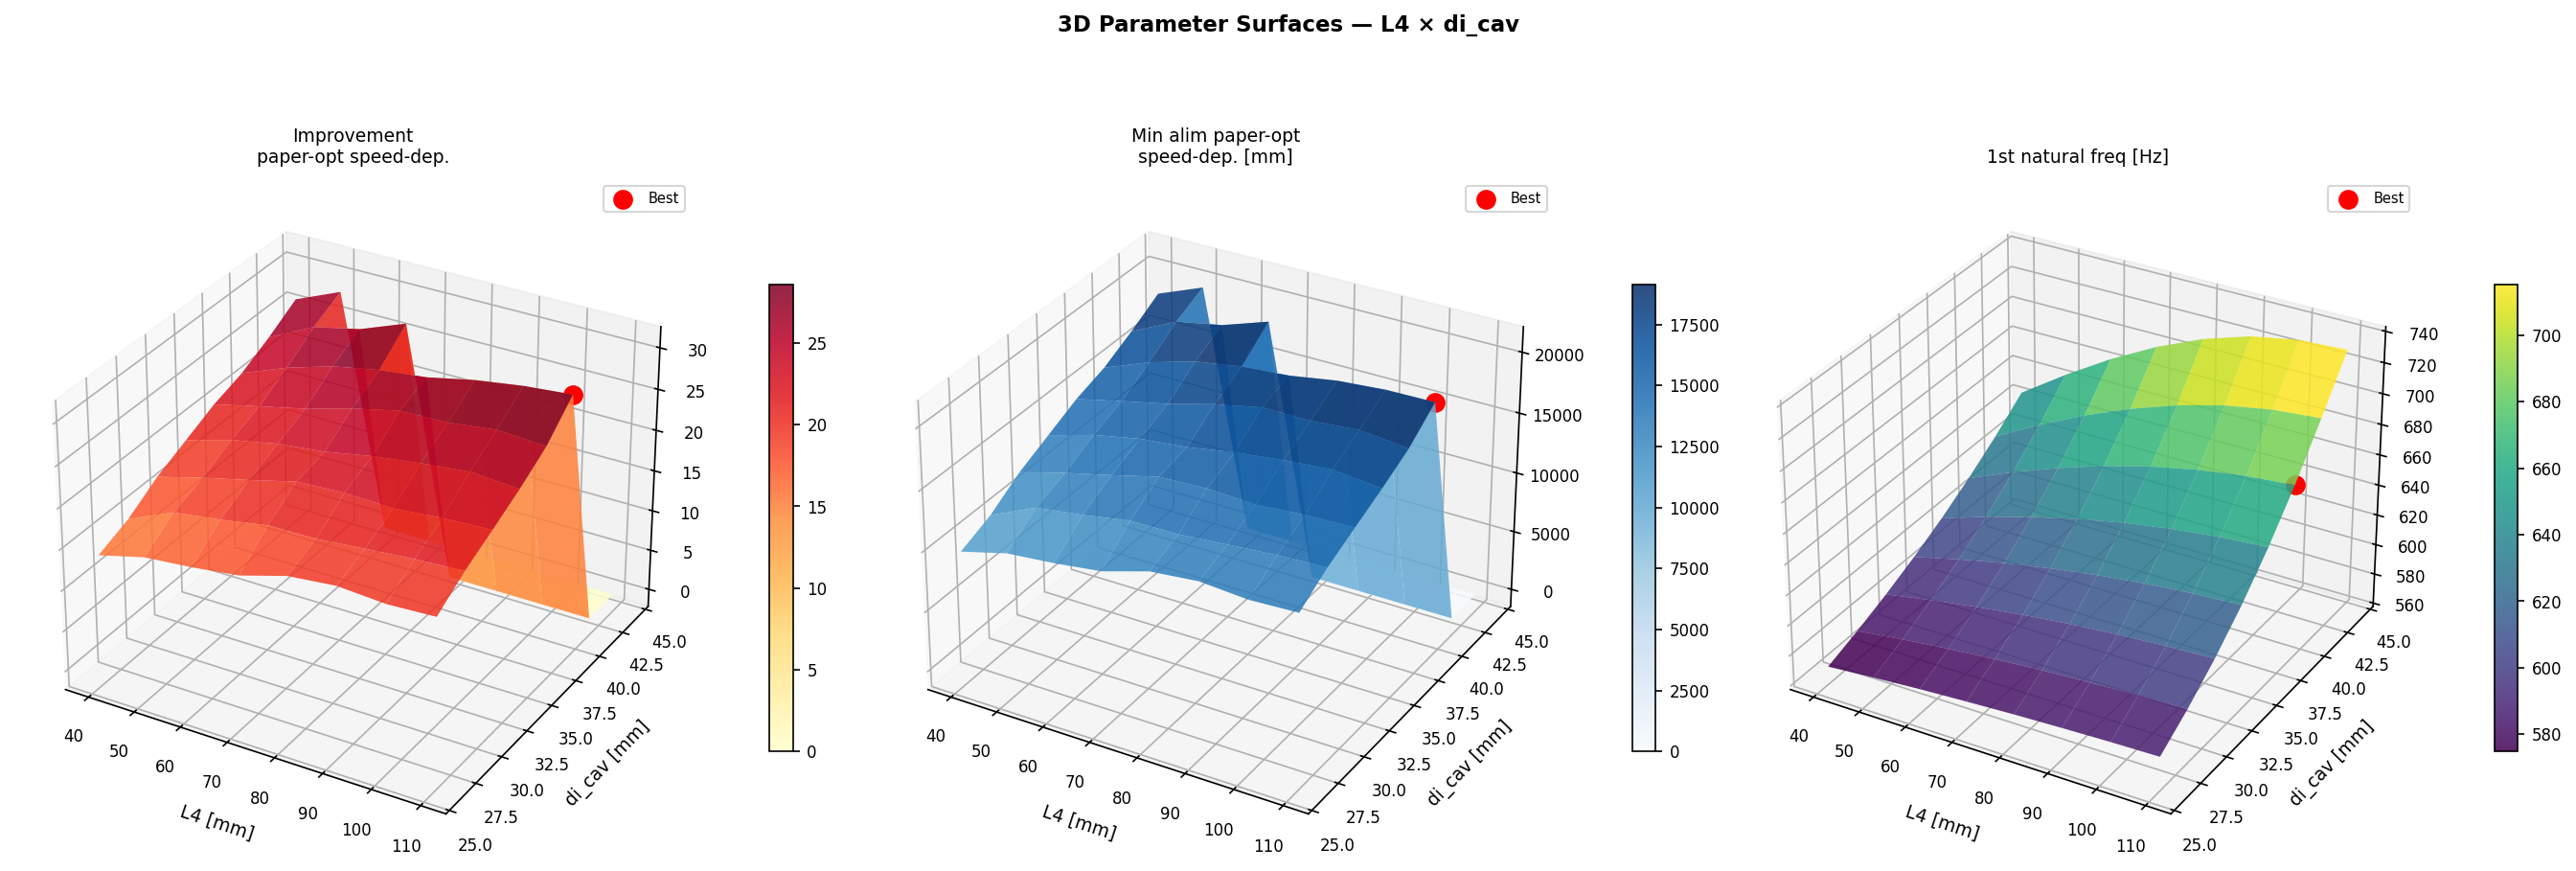

In [ ]:
# ── FIG 2 — 3D surfaces ────────────────────────────────────────────────────
fig2=plt.figure(figsize=(18,7)); fig2.suptitle("3D Parameter Surfaces — L4 × di_cav",fontsize=11,fontweight='bold')
L4M,DiM=np.meshgrid(L4_mm,di_mm,indexing='ij')
for idx,(data,title,cm) in enumerate([
    (ratio_opS_M,"Improvement\npaper-opt speed-dep.","YlOrRd"),
    (al_opS_M,   "Min alim paper-opt\nspeed-dep. [mm]","Blues"),
    (fn1_M,      "1st natural freq [Hz]","viridis")]):
    ax3=fig2.add_subplot(1,3,idx+1,projection='3d')
    zdat=np.where(np.isnan(data),np.nanmin(data),data)
    surf=ax3.plot_surface(L4M,DiM,zdat,cmap=cm,edgecolor='none',alpha=0.85)
    ax3.scatter([L4_best*1e3],[di_best*1e3],[data[i_b,j_b]],color='red',s=80,zorder=5,label='Best')
    ax3.set_xlabel("L4 [mm]",labelpad=5); ax3.set_ylabel("di_cav [mm]",labelpad=5)
    ax3.set_title(title,pad=8); fig2.colorbar(surf,ax=ax3,fraction=0.03,pad=0.1); ax3.legend(fontsize=7)
plt.tight_layout()
fig2.savefig(PLOT_DIR/f"surfaces_{RUN_ID}.png")
plt.show()

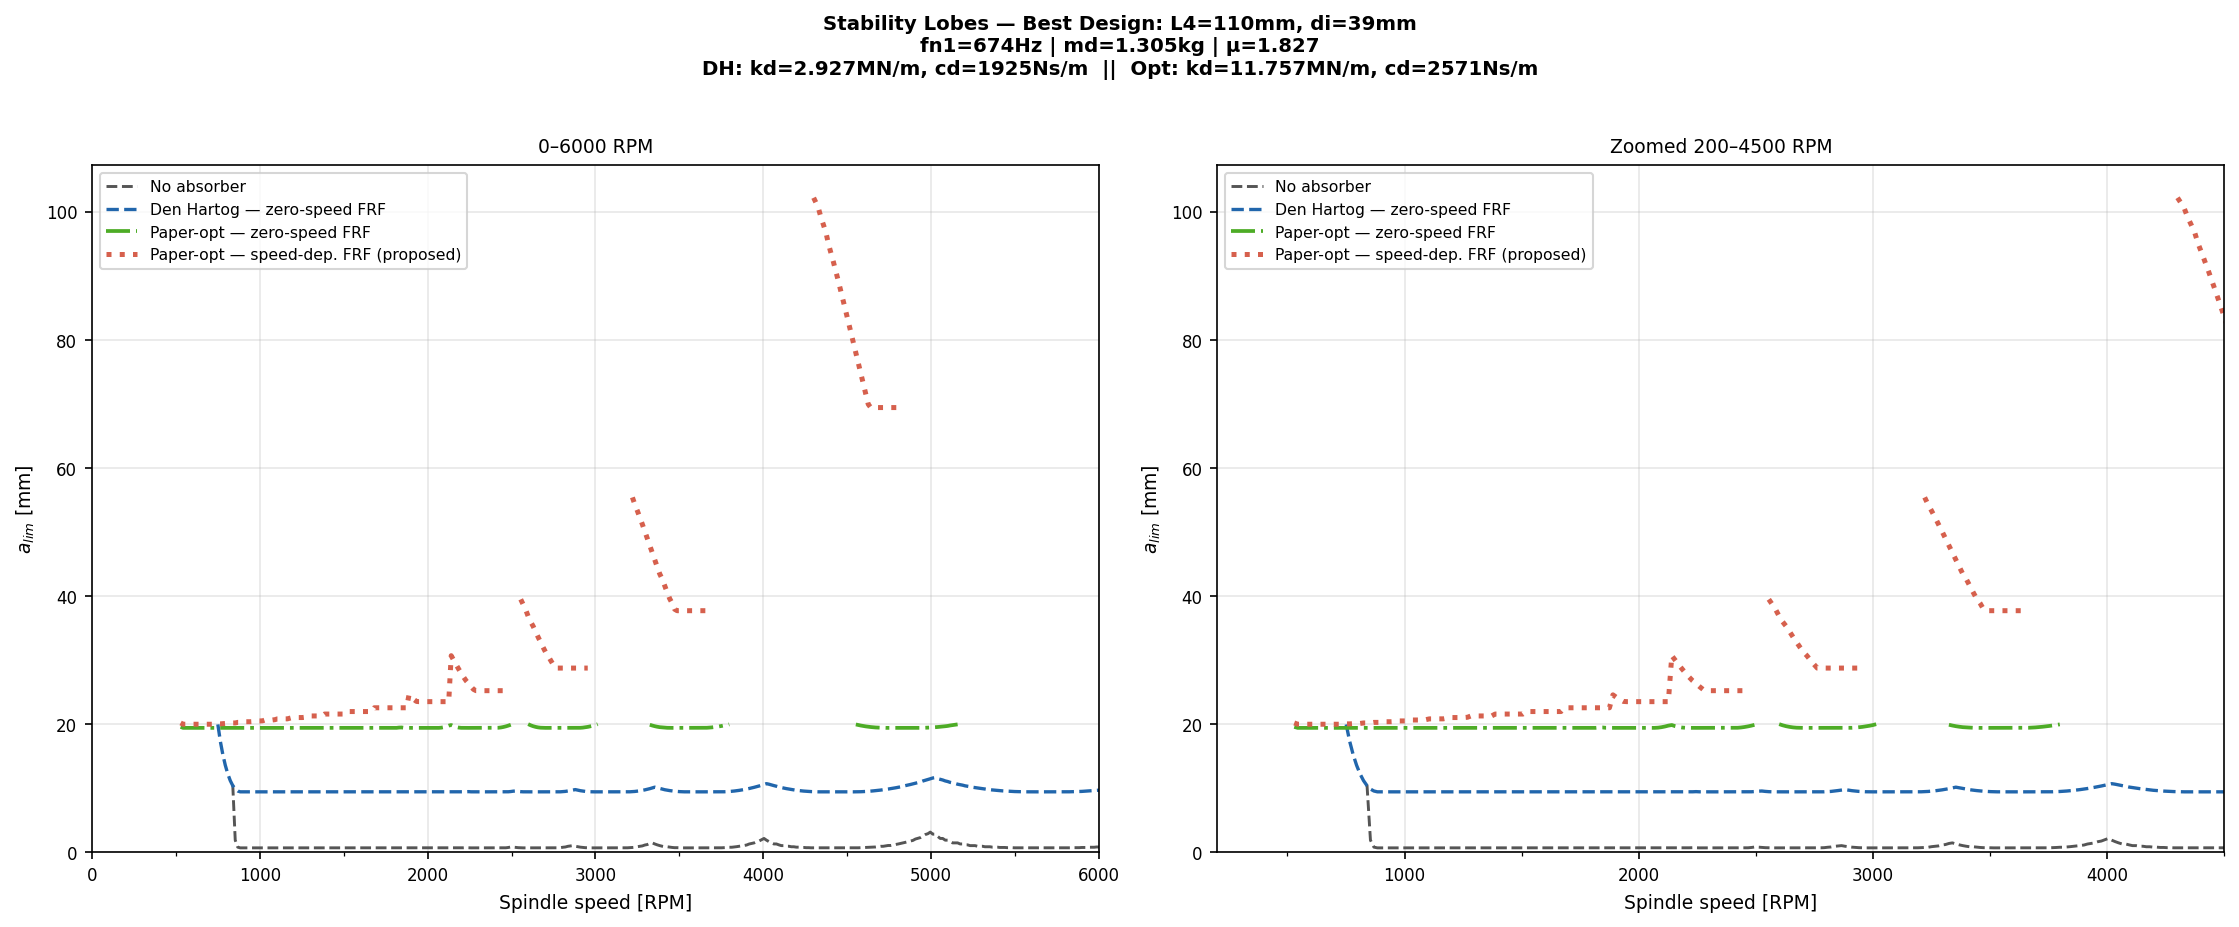

In [ ]:
# ── FIG 3 — Full stability lobes at best design ────────────────────────────
fig3,axes3=plt.subplots(1,2,figsize=(15,6))
fig3.suptitle(
    f"Stability Lobes — Best Design: L4={L4_best*1e3:.0f}mm, di={di_best*1e3:.0f}mm\n"
    f"fn1={fn1_M[i_b,j_b]:.0f}Hz | md={md_M[i_b,j_b]:.3f}kg | μ={mu_M[i_b,j_b]:.3f}\n"
    f"DH: kd={kd_dh_M[i_b,j_b]:.3f}MN/m, cd={cd_dh_M[i_b,j_b]:.0f}Ns/m  ||  "
    f"Opt: kd={kd_op_M[i_b,j_b]:.3f}MN/m, cd={cd_op_M[i_b,j_b]:.0f}Ns/m",
    fontsize=9.5,fontweight='bold',y=1.02)

LOBE_CFG=[
    (sto_b['env_na'],  "No absorber",                            "#555","--",1.4),
    (sto_b['env_dh'],  "Den Hartog — zero-speed FRF",            "#2166AC","--",1.6),
    (sto_b['env_op0'], "Paper-opt — zero-speed FRF",             "#4DAC26","-.",1.8),
    (sto_b['env_opS'], "Paper-opt — speed-dep. FRF (proposed)",  "#D6604D",":",2.4),
]
for ax_s in axes3:
    for env,lbl,col,ls,lw in LOBE_CFG:
        ax_s.plot(N_grid,env,color=col,ls=ls,lw=lw,label=lbl)
    ax_s.set_xlim(0,6000); ax_s.set_ylim(0,None)
    ax_s.set_xlabel("Spindle speed [RPM]"); ax_s.set_ylabel("$a_{lim}$ [mm]")
    ax_s.grid(True,alpha=0.3)
    ax_s.xaxis.set_major_locator(plt.MultipleLocator(1000))
    ax_s.xaxis.set_minor_locator(plt.MultipleLocator(500))
    ax_s.legend(fontsize=7.5)
axes3[0].set_title("0–6000 RPM")
axes3[1].set_xlim(200,4500); axes3[1].set_title("Zoomed 200–4500 RPM")
plt.tight_layout()
fig3.savefig(PLOT_DIR/f"lobes_{RUN_ID}.png")
plt.show()

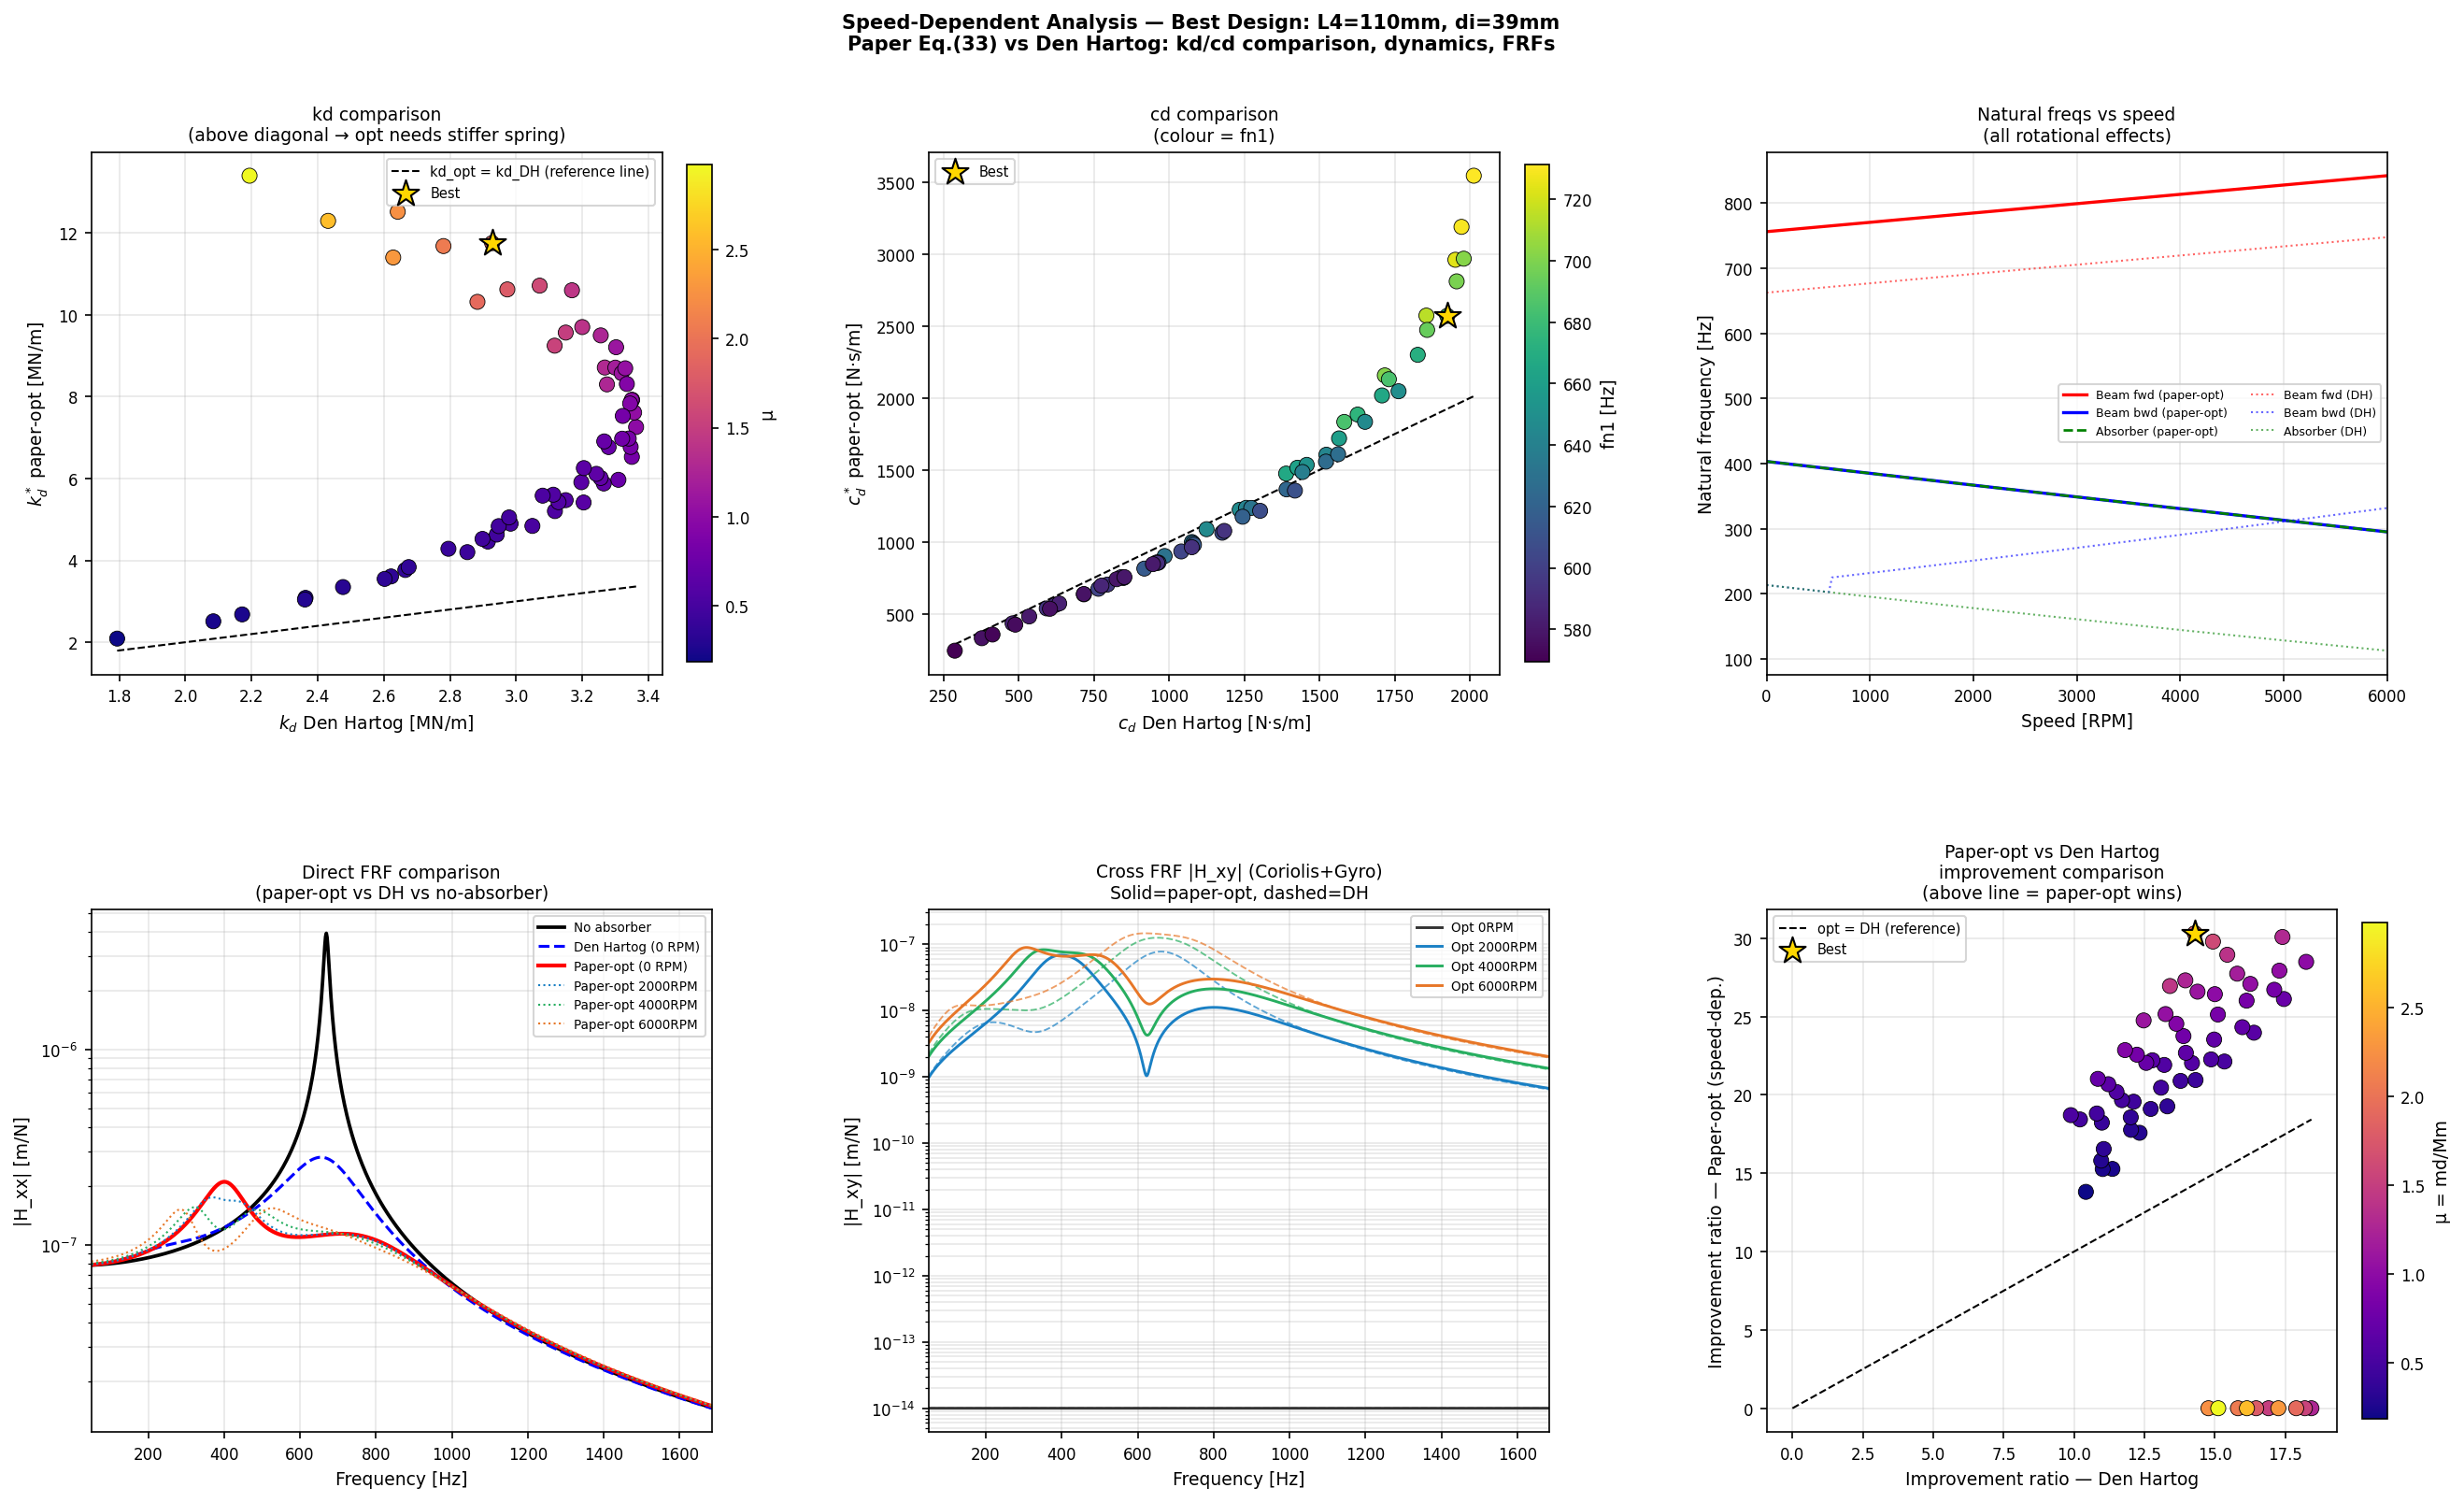

In [ ]:
# ── FIG 4 — kd/cd comparison (DH vs Opt) + nat-freq + FRF ─────────────────
fig4=plt.figure(figsize=(18,11))
fig4.suptitle(
    f"Speed-Dependent Analysis — Best Design: L4={L4_best*1e3:.0f}mm, di={di_best*1e3:.0f}mm\n"
    "Paper Eq.(33) vs Den Hartog: kd/cd comparison, dynamics, FRFs",
    fontsize=10,fontweight='bold',y=1.00)
gs4=gridspec.GridSpec(2,3,figure=fig4,hspace=0.45,wspace=0.35,
                       left=0.06,right=0.97,top=0.91,bottom=0.08)

# 4a — kd scatter: DH vs opt over full grid
ax4a=fig4.add_subplot(gs4[0,0])
sc=ax4a.scatter(kd_dh_M.ravel(),kd_op_M.ravel(),c=mu_M.ravel(),
                cmap='plasma',s=60,edgecolors='k',lw=0.4,zorder=3)
ax4a.plot([kd_dh_M.min(),kd_dh_M.max()],[kd_dh_M.min(),kd_dh_M.max()],
          'k--',lw=1,label='kd_opt = kd_DH (reference line)')
ax4a.scatter(kd_dh_M[i_b,j_b],kd_op_M[i_b,j_b],s=200,marker='*',
             color='gold',edgecolors='k',lw=1,zorder=5,label='Best')
plt.colorbar(sc,ax=ax4a,label='μ',fraction=0.04,pad=0.04)
ax4a.set_xlabel("$k_d$ Den Hartog [MN/m]"); ax4a.set_ylabel("$k_d^*$ paper-opt [MN/m]")
ax4a.set_title("kd comparison\n(above diagonal → opt needs stiffer spring)")
ax4a.legend(fontsize=7); ax4a.grid(True,alpha=0.3)

# 4b — cd scatter: DH vs opt
ax4b=fig4.add_subplot(gs4[0,1])
sc2=ax4b.scatter(cd_dh_M.ravel(),cd_op_M.ravel(),c=fn1_M.ravel(),
                 cmap='viridis',s=60,edgecolors='k',lw=0.4,zorder=3)
ax4b.plot([cd_dh_M.min(),cd_dh_M.max()],[cd_dh_M.min(),cd_dh_M.max()],
          'k--',lw=1)
ax4b.scatter(cd_dh_M[i_b,j_b],cd_op_M[i_b,j_b],s=200,marker='*',
             color='gold',edgecolors='k',lw=1,zorder=5,label='Best')
plt.colorbar(sc2,ax=ax4b,label='fn1 [Hz]',fraction=0.04,pad=0.04)
ax4b.set_xlabel("$c_d$ Den Hartog [N·s/m]"); ax4b.set_ylabel("$c_d^*$ paper-opt [N·s/m]")
ax4b.set_title("cd comparison\n(colour = fn1)")
ax4b.legend(fontsize=7); ax4b.grid(True,alpha=0.3)

# 4c — nat freqs vs speed (opt vs DH)
ax4c=fig4.add_subplot(gs4[0,2])
ax4c.plot(spd_plt,fw_opt,'r-', lw=1.6,label='Beam fwd (paper-opt)')
ax4c.plot(spd_plt,bw_opt,'b-', lw=1.6,label='Beam bwd (paper-opt)')
ax4c.plot(spd_plt,ab_opt,'g--',lw=1.3,label='Absorber (paper-opt)')
ax4c.plot(spd_plt,fw_dh, 'r:', lw=1.0,alpha=0.6,label='Beam fwd (DH)')
ax4c.plot(spd_plt,bw_dh, 'b:', lw=1.0,alpha=0.6,label='Beam bwd (DH)')
ax4c.plot(spd_plt,ab_dh, 'g:', lw=1.0,alpha=0.6,label='Absorber (DH)')
ax4c.set_xlabel("Speed [RPM]"); ax4c.set_ylabel("Natural frequency [Hz]")
ax4c.set_title("Natural freqs vs speed\n(all rotational effects)")
ax4c.set_xlim(0,6000); ax4c.legend(fontsize=6,ncol=2); ax4c.grid(True,alpha=0.3)

# 4d — Direct FRF: paper-opt vs DH vs no-abs at 0 RPM
ax4d=fig4.add_subplot(gs4[1,0])
M2,D2,K2=build_2x2(0.0,r_b)
FRF_na=[_frf(2*np.pi*f,M2,D2,K2,r_b['PSI_zf'])[0] for f in freqs_frf]
ax4d.semilogy(freqs_frf,np.abs(FRF_na),'k-',lw=1.8,label='No absorber')
ax4d.semilogy(freqs_frf,np.clip(FD_dh[0],1e-14,None),'b--',lw=1.5,label='Den Hartog (0 RPM)')
ax4d.semilogy(freqs_frf,np.clip(FD_opt[0],1e-14,None),'r-',lw=2.0,label='Paper-opt (0 RPM)')
for ii,rpm in enumerate(frf_rpms[1:],1):
    ax4d.semilogy(freqs_frf,np.clip(FD_opt[ii],1e-14,None),
                  color=clrs_frf[ii],ls=':',lw=1.0,label=f'Paper-opt {rpm}RPM')
ax4d.set_xlabel("Frequency [Hz]"); ax4d.set_ylabel("|H_xx| [m/N]")
ax4d.set_title("Direct FRF comparison\n(paper-opt vs DH vs no-absorber)")
ax4d.set_xlim(50,2.5*r_b['fn1']); ax4d.legend(fontsize=6.5); ax4d.grid(True,which='both',alpha=0.3)

# 4e — Cross FRF growth (Coriolis/Gyro) paper-opt vs DH
ax4e=fig4.add_subplot(gs4[1,1])
for ii,rpm in enumerate(frf_rpms):
    ax4e.semilogy(freqs_frf,np.clip(FC_opt[ii],1e-14,None),
                  color=clrs_frf[ii],ls='-',lw=1.4,label=f'Opt {rpm}RPM')
    ax4e.semilogy(freqs_frf,np.clip(FC_dh[ii],1e-14,None),
                  color=clrs_frf[ii],ls='--',lw=0.9,alpha=0.7)
ax4e.set_xlabel("Frequency [Hz]"); ax4e.set_ylabel("|H_xy| [m/N]")
ax4e.set_title("Cross FRF |H_xy| (Coriolis+Gyro)\nSolid=paper-opt, dashed=DH")
ax4e.set_xlim(50,2.5*r_b['fn1']); ax4e.legend(fontsize=6.5); ax4e.grid(True,which='both',alpha=0.3)

# 4f — improvement ratio: paper-opt-S vs DH scatter
ax4f=fig4.add_subplot(gs4[1,2])
sc3=ax4f.scatter(ratio_dh_M.ravel(),ratio_opS_M.ravel(),
                 c=mu_M.ravel(),cmap='plasma',s=60,edgecolors='k',lw=0.4,zorder=3)
ax4f.plot([0,ratio_dh_M.max()],[0,ratio_dh_M.max()],'k--',lw=1,
          label='opt = DH (reference)')
ax4f.scatter(ratio_dh_M[i_b,j_b],ratio_opS_M[i_b,j_b],s=200,marker='*',
             color='gold',edgecolors='k',lw=1,zorder=5,label='Best')
plt.colorbar(sc3,ax=ax4f,label='μ = md/Mm',fraction=0.04,pad=0.04)
ax4f.set_xlabel("Improvement ratio — Den Hartog")
ax4f.set_ylabel("Improvement ratio — Paper-opt (speed-dep.)")
ax4f.set_title("Paper-opt vs Den Hartog\nimprovement comparison\n(above line = paper-opt wins)")
ax4f.legend(fontsize=7); ax4f.grid(True,alpha=0.3)

plt.tight_layout()
fig4.savefig(PLOT_DIR/f"dynamics_{RUN_ID}.png")
plt.show()

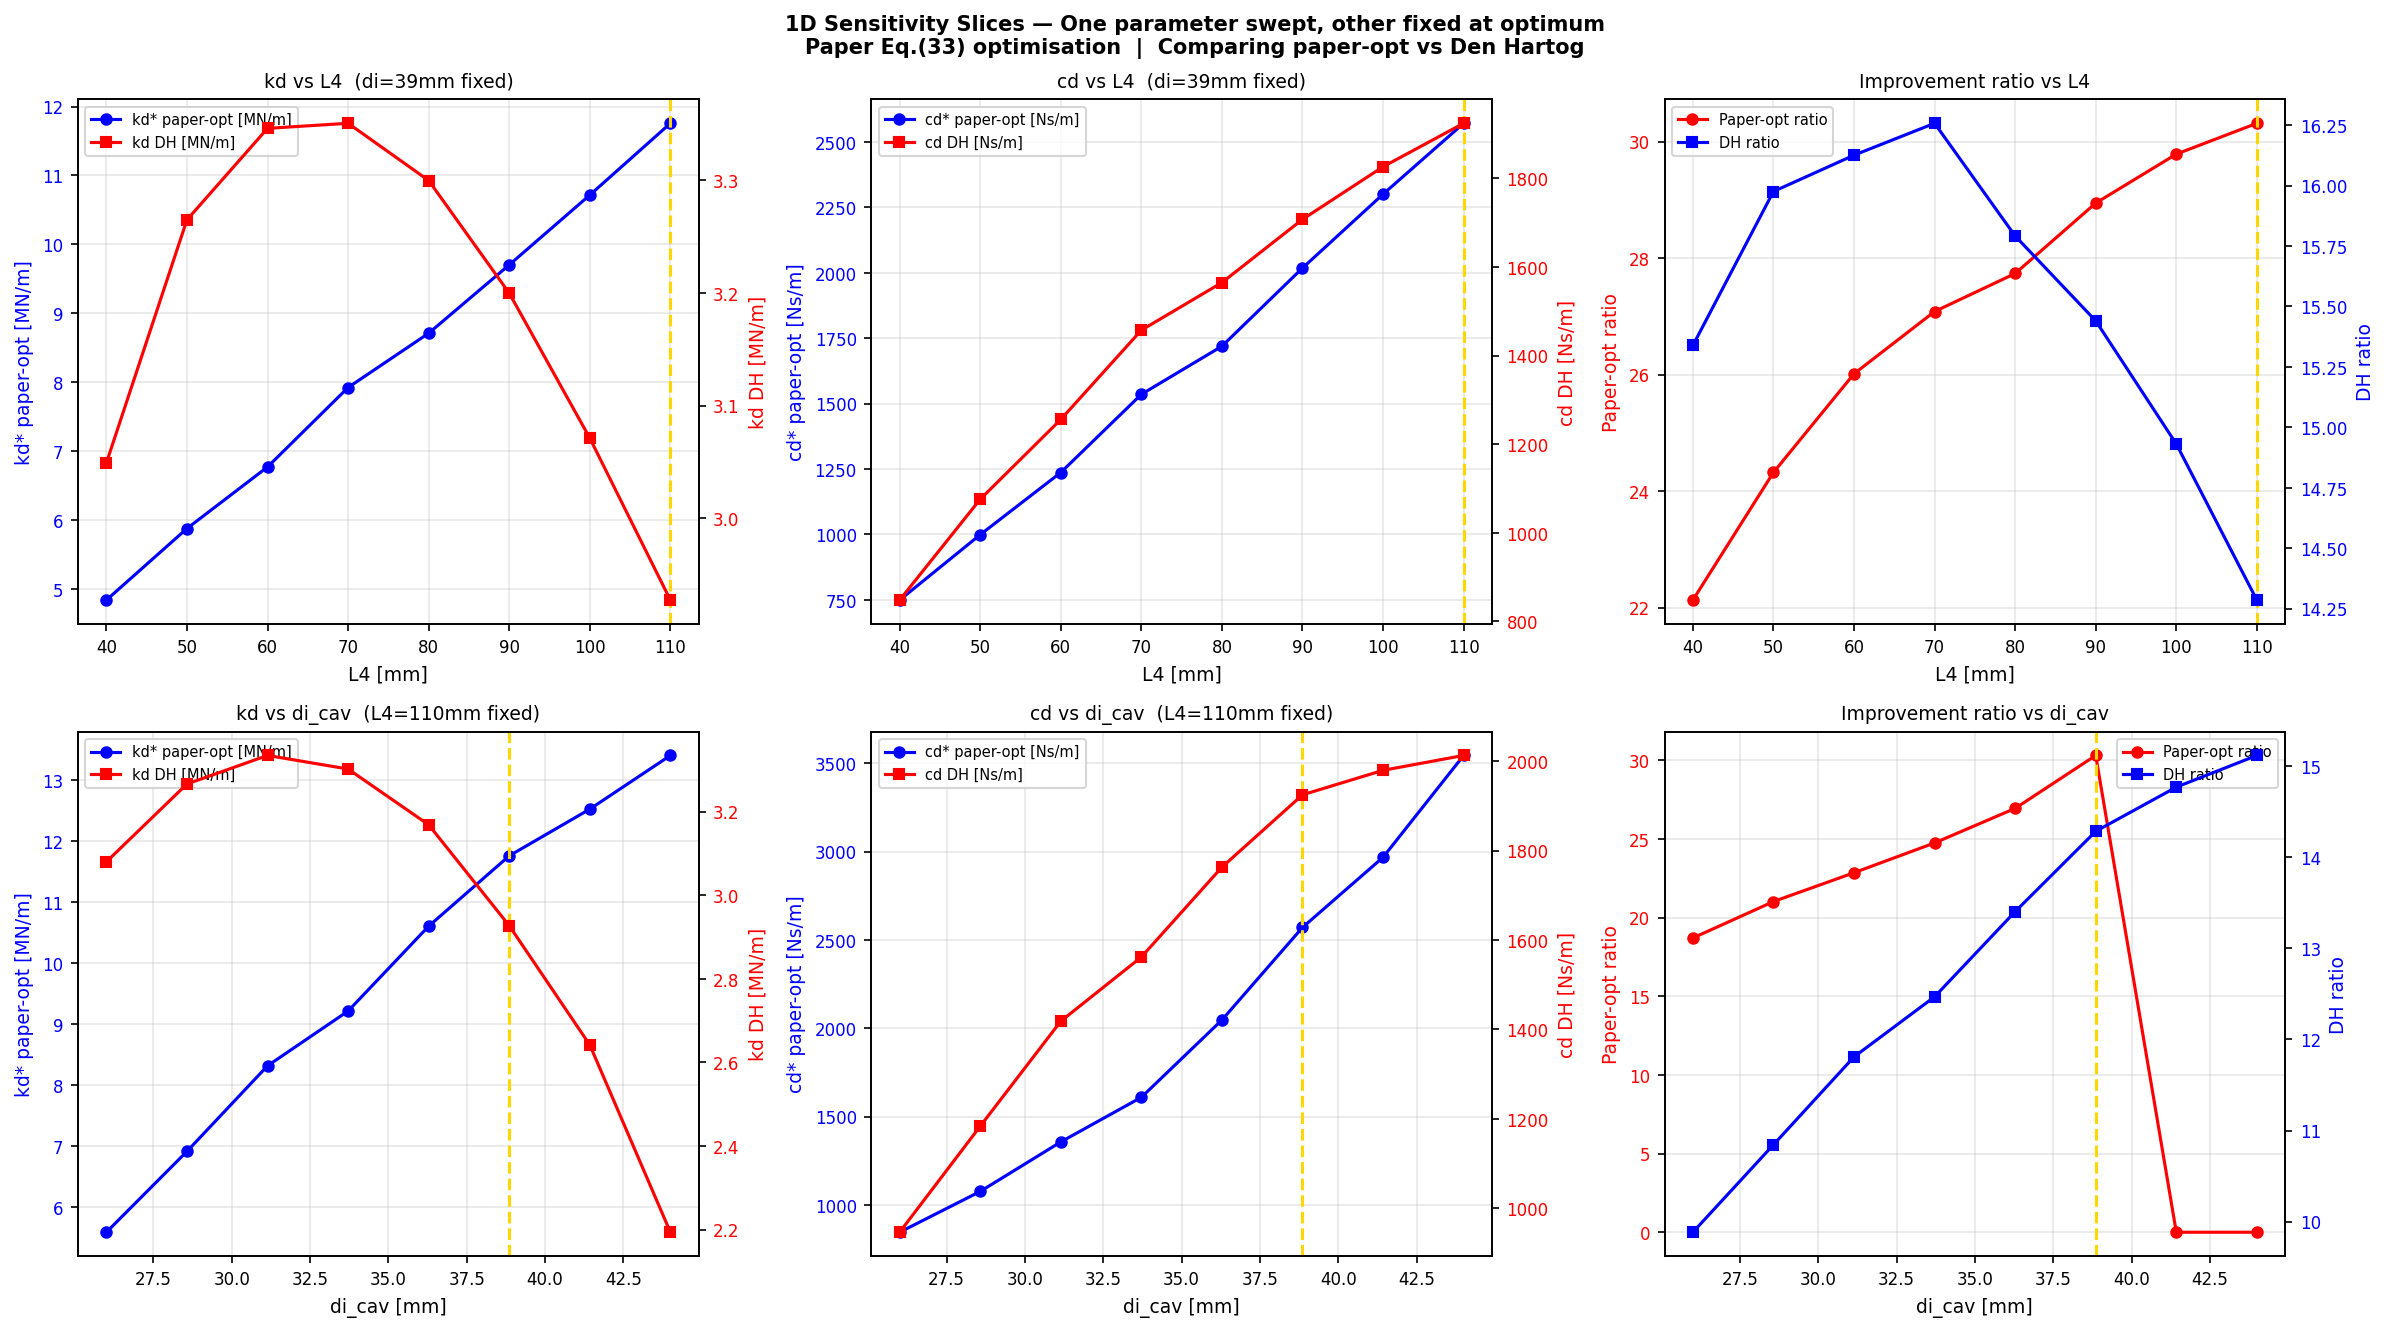

In [ ]:
# ── FIG 5 — 1D sensitivity slices ──────────────────────────────────────────
fig5,ax5=plt.subplots(2,3,figsize=(16,9))
fig5.suptitle(
    "1D Sensitivity Slices — One parameter swept, other fixed at optimum\n"
    "Paper Eq.(33) optimisation  |  Comparing paper-opt vs Den Hartog",
    fontsize=10,fontweight='bold')

def twin_ax(ax,x,y1,y2,lbl1,lbl2,c1='b',c2='r',title='',bx=None):
    ax2=ax.twinx()
    ax.plot(x,y1,f'{c1}-o',ms=5,label=lbl1)
    ax2.plot(x,y2,f'{c2}-s',ms=5,label=lbl2)
    if bx is not None: ax.axvline(bx,color='gold',ls='--',lw=1.5)
    ax.set_title(title); ax.set_ylabel(lbl1,color=c1); ax2.set_ylabel(lbl2,color=c2)
    ax.tick_params(axis='y',labelcolor=c1); ax2.tick_params(axis='y',labelcolor=c2)
    l1,lb1=ax.get_legend_handles_labels(); l2,lb2=ax2.get_legend_handles_labels()
    ax.legend(l1+l2,lb1+lb2,fontsize=7); ax.grid(True,alpha=0.3); return ax2

# Slices along L4 (di fixed at best)
L4s_fn1=fn1_M[:,j_b]; L4s_kd_opt=kd_op_M[:,j_b]; L4s_kd_dh=kd_dh_M[:,j_b]
L4s_cd_opt=cd_op_M[:,j_b]; L4s_cd_dh=cd_dh_M[:,j_b]
L4s_rat_S=ratio_opS_M[:,j_b]; L4s_rat_dh=ratio_dh_M[:,j_b]

twin_ax(ax5[0,0],L4_mm,L4s_kd_opt,L4s_kd_dh,'kd* paper-opt [MN/m]','kd DH [MN/m]',
        title=f"kd vs L4  (di={di_best*1e3:.0f}mm fixed)",bx=L4_best*1e3)
ax5[0,0].set_xlabel("L4 [mm]")

twin_ax(ax5[0,1],L4_mm,L4s_cd_opt,L4s_cd_dh,'cd* paper-opt [Ns/m]','cd DH [Ns/m]',
        title=f"cd vs L4  (di={di_best*1e3:.0f}mm fixed)",bx=L4_best*1e3)
ax5[0,1].set_xlabel("L4 [mm]")

twin_ax(ax5[0,2],L4_mm,L4s_rat_S,L4s_rat_dh,'Paper-opt ratio','DH ratio','r','b',
        title=f"Improvement ratio vs L4",bx=L4_best*1e3)
ax5[0,2].set_xlabel("L4 [mm]")

# Slices along di_cav (L4 fixed at best)
di_s_kd_opt=kd_op_M[i_b,:]; di_s_kd_dh=kd_dh_M[i_b,:]
di_s_cd_opt=cd_op_M[i_b,:]; di_s_cd_dh=cd_dh_M[i_b,:]
di_s_rat_S=ratio_opS_M[i_b,:]; di_s_rat_dh=ratio_dh_M[i_b,:]

twin_ax(ax5[1,0],di_mm,di_s_kd_opt,di_s_kd_dh,'kd* paper-opt [MN/m]','kd DH [MN/m]',
        title=f"kd vs di_cav  (L4={L4_best*1e3:.0f}mm fixed)",bx=di_best*1e3)
ax5[1,0].set_xlabel("di_cav [mm]")

twin_ax(ax5[1,1],di_mm,di_s_cd_opt,di_s_cd_dh,'cd* paper-opt [Ns/m]','cd DH [Ns/m]',
        title=f"cd vs di_cav  (L4={L4_best*1e3:.0f}mm fixed)",bx=di_best*1e3)
ax5[1,1].set_xlabel("di_cav [mm]")

twin_ax(ax5[1,2],di_mm,di_s_rat_S,di_s_rat_dh,'Paper-opt ratio','DH ratio','r','b',
        title="Improvement ratio vs di_cav",bx=di_best*1e3)
ax5[1,2].set_xlabel("di_cav [mm]")

plt.tight_layout()
fig5.savefig(PLOT_DIR/f"sensitivity_{RUN_ID}.png")
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 12.  FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════
print("\n"+"="*70)
print("COMPLETE RESULTS TABLE — Paper Eq.(33) vs Den Hartog")
print("="*70)
print(f"  {'L4':>6} {'di':>5} {'wall':>5} {'fn1':>7} {'Mm':>7} {'md':>7} "
      f"{'μ':>6} {'kd_DH':>8} {'kd_opt':>8} {'cd_DH':>7} {'cd_opt':>7} "
      f"{'al_na':>7} {'al_DH':>7} {'al_op0':>7} {'al_opS':>7} "
      f"{'r_DH':>6} {'r_op0':>6} {'r_opS':>6}")
print("-"*140)
for i,L4 in enumerate(L4_arr):
    for j,di in enumerate(di_arr):
        if np.isnan(fn1_M[i,j]): continue
        wall=(D_main-di)/2
        print(f"  {L4*1e3:5.0f}  {di*1e3:5.0f}  {wall*1e3:5.1f}  "
              f"{fn1_M[i,j]:7.1f}  {Mm_M[i,j]:7.4f}  {md_M[i,j]:7.4f}  "
              f"{mu_M[i,j]:6.3f}  {kd_dh_M[i,j]:8.3f}  {kd_op_M[i,j]:8.3f}  "
              f"{cd_dh_M[i,j]:7.1f}  {cd_op_M[i,j]:7.1f}  "
              f"{al_na_M[i,j]:7.4f}  {al_dh_M[i,j]:7.4f}  "
              f"{al_op0_M[i,j]:7.4f}  {al_opS_M[i,j]:7.4f}  "
              f"{ratio_dh_M[i,j]:6.2f}×  {ratio_op0_M[i,j]:6.2f}×  {ratio_opS_M[i,j]:6.2f}×")

print(f"\n{'='*70}")
print("OPTIMAL DESIGN")
print(f"{'='*70}")
print(f"  Parameter 1 (position from free end): L_free = {L_FREE*1e3:.0f} mm (fixed)")
print(f"  Parameter 2 (cavity length)          : L4    = {L4_best*1e3:.0f} mm")
print(f"  Parameter 3 (cavity diameter)        : di    = {di_best*1e3:.0f} mm  "
      f"(wall={(D_main-di_best)/2*1e3:.0f} mm)")
print(f"  fn1 = {fn1_M[i_b,j_b]:.1f} Hz  |  Mm = {Mm_M[i_b,j_b]:.4f} kg  "
      f"|  md = {md_M[i_b,j_b]:.4f} kg  |  μ = {mu_M[i_b,j_b]:.4f}")
print(f"")
print(f"  Den Hartog : kd = {kd_dh_M[i_b,j_b]:.4f} MN/m,  cd = {cd_dh_M[i_b,j_b]:.1f} N·s/m")
print(f"  Paper Eq.33: kd = {kd_op_M[i_b,j_b]:.4f} MN/m,  cd = {cd_op_M[i_b,j_b]:.1f} N·s/m")
print(f"  (kd ratio paper/DH = {kd_op_M[i_b,j_b]/kd_dh_M[i_b,j_b]:.2f}×,  "
      f"cd ratio = {cd_op_M[i_b,j_b]/cd_dh_M[i_b,j_b]:.2f}×)")
print(f"")
print(f"  Stability improvement:")
print(f"    Den Hartog (zero-speed)            : {ratio_dh_M[i_b,j_b]:.2f}×")
print(f"    Paper-opt (zero-speed FRF)         : {ratio_op0_M[i_b,j_b]:.2f}×")
print(f"    Paper-opt (speed-dep. FRF)         : {ratio_opS_M[i_b,j_b]:.2f}×  ← proposed method")
print(f"")
print("SAVED: p23_heatmaps.png | p23_3D.png | p23_lobes_best.png | p23_dynamics.png | p23_sensitivity.png")


COMPLETE RESULTS TABLE — Paper Eq.(33) vs Den Hartog
      L4    di  wall     fn1      Mm      md      μ    kd_DH   kd_opt   cd_DH  cd_opt   al_na   al_DH  al_op0  al_opS   r_DH  r_op0  r_opS
--------------------------------------------------------------------------------------------------------------------------------------------
     40     26   12.0    569.5   1.0622   0.1968   0.185     1.794     2.089    287.7    244.1  700.1640  7294.8931  9471.3815  9669.5004   10.42×   13.53×   13.81×
     40     29   10.7    576.8   1.0359   0.2412   0.233     2.084     2.511    377.4    330.6  700.8152  7962.1994  10541.9987  10704.4000   11.36×   15.04×   15.27×
     40     31    9.4    585.1   1.0071   0.2902   0.288     2.363     3.084    479.7    433.9  700.6470  8636.4521  12464.0000  12316.9982   12.33×   17.79×   17.58×
     40     34    8.1    594.4   0.9758   0.3436   0.352     2.622     3.608    593.2    537.6  700.2788  9321.0187  13556.1406  13492.6537   13.31×   19.36×   19.27×


In [ ]:
full_results = {

    "fn1_M": fn1_M,

    "Mm_M": Mm_M,

    "md_M": md_M,

    "mu_M": mu_M,

    "kd_dh_M": kd_dh_M,

    "cd_dh_M": cd_dh_M,

    "kd_op_M": kd_op_M,

    "cd_op_M": cd_op_M,

    "ratio_opS_M": ratio_opS_M,

    "best_idx": best_idx,

    "worst_idx": worst_idx
}

with open(
    RESULT_DIR /
    f"full_run_{RUN_ID}.pkl",
    "wb"
) as f:

    pickle.dump(
        full_results,
        f
    )